# Data Merging: Tesla Stock Data, Web Scraping News and REST API News

In this notebook, the cleaned Tesla stock data is combined with two news datasets:

1. Tesla stock prices from a CSV file
2. Tesla-related news from web scraping
3. Tesla-related news from the Alpha Vantage REST API

The goal is to create one combined dataset for the story: **How do Tesla-related news volume and sentiment appear around the available Tesla stock data?**

Important implementation choice: the final merge uses an **outer date spine**. This keeps newer news days even when the local stock CSV does not yet contain matching market prices. This is important because otherwise the REST API data would disappear from the final result when the stock data ends earlier than the news data.

# Imports

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Load Data

In [2]:
stock_df = pd.read_csv("../data/processed/tesla_stock_data_cleaned.csv")
scraped_news_df = pd.read_csv("../data/processed/tesla_news_cleaned.csv")
api_news_df = pd.read_csv("../data/processed/alpha_vantage_tesla_news_cleaned.csv")

print("Stock data:", stock_df.shape)
print("Scraped news data:", scraped_news_df.shape)
print("API news data:", api_news_df.shape)

display(stock_df.head())
display(scraped_news_df.head())
display(api_news_df.head())

Stock data: (1588, 10)
Scraped news data: (99, 5)
API news data: (50, 8)


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100
0,2020-01-03,29.3667,30.2667,29.1280,29.5340,266920455,NaN,1.1387,NaN,NaN
1,2020-01-06,29.3647,30.1040,29.3333,30.1027,152362485,0.019256,0.7707,NaN,NaN
2,2020-01-07,30.7600,31.4420,30.2237,31.2707,273137070,0.038801,1.2183,NaN,NaN
3,2020-01-08,31.5800,33.2333,31.2153,32.8093,467990895,0.049203,2.0180,NaN,NaN
4,2020-01-09,33.1400,33.2533,31.5247,32.0893,426947790,-0.021945,1.7286,NaN,NaN


,title,link,published_at,source,date
0,Tesla (TSLA) Stock Hits $420 in July 2026 — AI...,https://news.google.com/rss/articles/CBMiwAFBV...,2026-07-01 11:25:18+00:00,FXLeaders,2026-07-01
1,Tesla Deliveries Should Show a Second Straight...,https://news.google.com/rss/articles/CBMiowFBV...,2026-07-01 11:17:00+00:00,Barron's,2026-07-01
2,"Michael Burry shorts Tesla at $416, betting on...",https://news.google.com/rss/articles/CBMirwFBV...,2026-07-01 11:01:18+00:00,Pluang,2026-07-01
3,Tesla registrations in Spain climb 5.6% in Jun...,https://news.google.com/rss/articles/CBMiqwFBV...,2026-07-01 10:51:55+00:00,Investing.com,2026-07-01
4,Tesla Semi Puts PACCAR Stock And Electric Truc...,https://news.google.com/rss/articles/CBMiygFBV...,2026-07-01 10:42:51+00:00,simplywall.st,2026-07-01


,title,url,time_published,summary,source,overall_sentiment_score,overall_sentiment_label,date
0,UBS reiterates Packaging Corp. of America stoc...,https://ca.investing.com/news/stock-market-new...,2026-06-11 14:38:29,UBS has reiterated a Buy rating and a $248.00 ...,Investing.com Canada,0.049732,Neutral,2026-06-11
1,Oppenheimer raises Tesla stock price target on...,https://www.investing.com/news/analyst-ratings...,2026-06-11 13:25:40,Oppenheimer has increased its price target for...,Investing.com,0.203912,Somewhat-Bullish,2026-06-11
2,Is the 2026 Toyota bZ Woodland a Good Crossove...,https://www.cars.com/articles/is-the-2026-toyo...,2026-06-11 11:39:09,The 2026 Toyota bZ Woodland is an electric cro...,Cars.com,0.037104,Neutral,2026-06-11
3,"General Motors pivots battery strategy, puts L...",https://seekingalpha.com/news/4602466-general-...,2026-06-11 09:27:02,General Motors is reportedly shifting its elec...,Seeking Alpha,0.138295,Neutral,2026-06-11
4,Musk to discuss Terafab chip plant plans at AS...,https://seekingalpha.com/news/4602459-musk-to-...,2026-06-11 08:10:40,Elon Musk is scheduled to virtually attend ASM...,Seeking Alpha,0.172115,Somewhat-Bullish,2026-06-11


# Convert Date Columns

In [3]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])
scraped_news_df["date"] = pd.to_datetime(scraped_news_df["date"])
api_news_df["date"] = pd.to_datetime(api_news_df["date"])

print("Stock date range:", stock_df["Date"].min(), "to", stock_df["Date"].max())
print("Scraped news date range:", scraped_news_df["date"].min(), "to", scraped_news_df["date"].max())
print("API news date range:", api_news_df["date"].min(), "to", api_news_df["date"].max())

Stock date range: 2020-01-03 00:00:00 to 2026-04-29 00:00:00
Scraped news date range: 2026-06-01 00:00:00 to 2026-07-01 00:00:00
API news date range: 2026-06-09 00:00:00 to 2026-06-11 00:00:00


# Aggregate Web Scraping News per Day

In [4]:
scraped_daily = scraped_news_df.groupby("date").agg(
    scraped_news_count=("title", "count"),
    scraped_sources=("source", lambda x: ", ".join(sorted(set(x.dropna().astype(str))))),
    scraped_titles=("title", lambda x: " | ".join(x.dropna().astype(str).head(3)))
).reset_index()

display(scraped_daily.head())

,date,scraped_news_count,scraped_sources,scraped_titles
0,2026-06-01,1,Yahoo Finance,Reports of a Future SpaceX-Tesla Merger Are Pi...
1,2026-06-03,1,Yahoo Finance,Tesla Stock Tests Short-Term Moving Averages A...
2,2026-06-04,1,Yahoo Finance,Where Will Tesla Stock Be in 3 Years? - Yahoo ...
3,2026-06-05,1,Yahoo Finance,Why Tesla (TSLA) Shares Are Trading Lower Toda...
4,2026-06-08,2,"Barron's, Yahoo Finance",Tesla Stock Rises Ahead of SpaceX’s Friday IPO...


# Aggregate REST API News per Day

In [5]:
import numpy as np

# Compatibility fix in case the API notebook produced an older CSV
if "tsla_sentiment_score" not in api_news_df.columns:
    api_news_df["tsla_sentiment_score"] = np.nan

if "tsla_relevance_score" not in api_news_df.columns:
    api_news_df["tsla_relevance_score"] = np.nan

if "tsla_sentiment_label" not in api_news_df.columns:
    api_news_df["tsla_sentiment_label"] = None

# Make sure numeric columns are really numeric
api_news_df["overall_sentiment_score"] = pd.to_numeric(
    api_news_df["overall_sentiment_score"], errors="coerce"
)

api_news_df["tsla_sentiment_score"] = pd.to_numeric(
    api_news_df["tsla_sentiment_score"], errors="coerce"
)

api_news_df["tsla_relevance_score"] = pd.to_numeric(
    api_news_df["tsla_relevance_score"], errors="coerce"
)

print(api_news_df.columns.tolist())

['title', 'url', 'time_published', 'summary', 'source', 'overall_sentiment_score', 'overall_sentiment_label', 'date', 'tsla_sentiment_score', 'tsla_relevance_score', 'tsla_sentiment_label']


In [6]:
api_daily = api_news_df.groupby("date").agg(
    api_news_count=("title", "count"),
    avg_api_sentiment=("overall_sentiment_score", "mean"),
    avg_tsla_sentiment=("tsla_sentiment_score", "mean"),
    avg_tsla_relevance=("tsla_relevance_score", "mean"),
    api_sentiment_labels=("overall_sentiment_label", lambda x: ", ".join(sorted(set(x.dropna().astype(str))))),
    tsla_sentiment_labels=("tsla_sentiment_label", lambda x: ", ".join(sorted(set(x.dropna().astype(str))))),
    api_titles=("title", lambda x: " | ".join(x.dropna().astype(str).head(3)))
).reset_index()

api_daily.head()

,date,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles
0,2026-06-09,19,0.113681,NaN,NaN,"Bullish, Neutral, Somewhat-Bearish, Somewhat-B...",,"[Form 4] Tesla, Inc. Insider Trading Activity ..."
1,2026-06-10,22,0.033082,NaN,NaN,"Bearish, Neutral, Somewhat-Bearish, Somewhat-B...",,"Sylebra Capital LLC, an Impinj director, sells..."
2,2026-06-11,9,0.133557,NaN,NaN,"Neutral, Somewhat-Bullish",,UBS reiterates Packaging Corp. of America stoc...


# Create Date Spine for News Period

In [7]:
min_news_date = min(scraped_news_df["date"].min(), api_news_df["date"].min())
max_news_date = max(scraped_news_df["date"].max(), api_news_df["date"].max())

all_dates = pd.DataFrame({
    "Date": sorted(
        set(stock_df["Date"]) |
        set(scraped_daily["date"]) |
        set(api_daily["date"])
    )
})

all_dates = all_dates[
    (all_dates["Date"] >= min_news_date) &
    (all_dates["Date"] <= max_news_date)
].copy()

print("News date range:", min_news_date, "to", max_news_date)
print("Date spine rows:", all_dates.shape[0])
print("Stock rows in this period:", stock_df[(stock_df["Date"] >= min_news_date) & (stock_df["Date"] <= max_news_date)].shape[0])

News date range: 2026-06-01 00:00:00 to 2026-07-01 00:00:00
Date spine rows: 21
Stock rows in this period: 0


# Merge All Data

In [8]:
merged_df = all_dates.merge(stock_df, on="Date", how="left")

merged_df = merged_df.merge(
    scraped_daily.rename(columns={"date": "Date"}),
    on="Date",
    how="left"
)

merged_df = merged_df.merge(
    api_daily.rename(columns={"date": "Date"}),
    on="Date",
    how="left"
)

print("Merged dataset shape:", merged_df.shape)
merged_df.head()

Merged dataset shape: (21, 20)


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100,scraped_news_count,scraped_sources,scraped_titles,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles
0,2026-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Yahoo Finance,Reports of a Future SpaceX-Tesla Merger Are Pi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Yahoo Finance,Tesla Stock Tests Short-Term Moving Averages A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Yahoo Finance,Where Will Tesla Stock Be in 3 Years? - Yahoo ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Yahoo Finance,Why Tesla (TSLA) Shares Are Trading Lower Toda...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,"Barron's, Yahoo Finance",Tesla Stock Rises Ahead of SpaceX’s Friday IPO...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Fill Missing Values and Add Flags

In [9]:
for count_col in ["scraped_news_count", "api_news_count"]:
    merged_df[count_col] = merged_df[count_col].fillna(0).astype(int)

for sentiment_col in ["avg_api_sentiment", "avg_tsla_sentiment", "avg_tsla_relevance"]:
    merged_df[sentiment_col] = merged_df[sentiment_col].fillna(0)

text_columns = [
    "scraped_sources",
    "scraped_titles",
    "api_sentiment_labels",
    "tsla_sentiment_labels",
    "api_titles"
]

for column in text_columns:
    merged_df[column] = merged_df[column].fillna("")

merged_df["has_stock_data"] = merged_df["Close"].notna()
merged_df["total_news_count"] = merged_df["scraped_news_count"] + merged_df["api_news_count"]

print("Rows with stock data:", merged_df["has_stock_data"].sum())
print("Rows with scraped news:", (merged_df["scraped_news_count"] > 0).sum())
print("Rows with REST API news:", (merged_df["api_news_count"] > 0).sum())
print("Total scraped news:", merged_df["scraped_news_count"].sum())
print("Total API news:", merged_df["api_news_count"].sum())

merged_df.head()

Rows with stock data: 0
Rows with scraped news: 21
Rows with REST API news: 3
Total scraped news: 99
Total API news: 50


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100,...,scraped_titles,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles,has_stock_data,total_news_count
0,2026-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Reports of a Future SpaceX-Tesla Merger Are Pi...,0,0.0,0.0,0.0,,,,False,1
1,2026-06-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tesla Stock Tests Short-Term Moving Averages A...,0,0.0,0.0,0.0,,,,False,1
2,2026-06-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Where Will Tesla Stock Be in 3 Years? - Yahoo ...,0,0.0,0.0,0.0,,,,False,1
3,2026-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Why Tesla (TSLA) Shares Are Trading Lower Toda...,0,0.0,0.0,0.0,,,,False,1
4,2026-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tesla Stock Rises Ahead of SpaceX’s Friday IPO...,0,0.0,0.0,0.0,,,,False,2


# Save Merged Dataset

In [10]:
os.makedirs("../data/results", exist_ok=True)

merged_df.to_csv("../data/results/tesla_stock_news_merged.csv", index=False)

print("Saved merged data to ../data/results/tesla_stock_news_merged.csv")
print("Final shape:", merged_df.shape)

Saved merged data to ../data/results/tesla_stock_news_merged.csv
Final shape: (21, 22)


# Quick Check

In [11]:
check_df = pd.read_csv("../data/results/tesla_stock_news_merged.csv")

print("File loaded successfully.")
print("Rows:", len(check_df))
print("Columns:", list(check_df.columns))

display(check_df.head())

File loaded successfully.
Rows: 21
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Price_Range', 'MA_30', 'MA_100', 'scraped_news_count', 'scraped_sources', 'scraped_titles', 'api_news_count', 'avg_api_sentiment', 'avg_tsla_sentiment', 'avg_tsla_relevance', 'api_sentiment_labels', 'tsla_sentiment_labels', 'api_titles', 'has_stock_data', 'total_news_count']


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100,...,scraped_titles,api_news_count,avg_api_sentiment,avg_tsla_sentiment,avg_tsla_relevance,api_sentiment_labels,tsla_sentiment_labels,api_titles,has_stock_data,total_news_count
0,2026-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Reports of a Future SpaceX-Tesla Merger Are Pi...,0,0.0,0.0,0.0,NaN,NaN,NaN,False,1
1,2026-06-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tesla Stock Tests Short-Term Moving Averages A...,0,0.0,0.0,0.0,NaN,NaN,NaN,False,1
2,2026-06-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Where Will Tesla Stock Be in 3 Years? - Yahoo ...,0,0.0,0.0,0.0,NaN,NaN,NaN,False,1
3,2026-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Why Tesla (TSLA) Shares Are Trading Lower Toda...,0,0.0,0.0,0.0,NaN,NaN,NaN,False,1
4,2026-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tesla Stock Rises Ahead of SpaceX’s Friday IPO...,0,0.0,0.0,0.0,NaN,NaN,NaN,False,2


# Visualization: News Volume Over Time

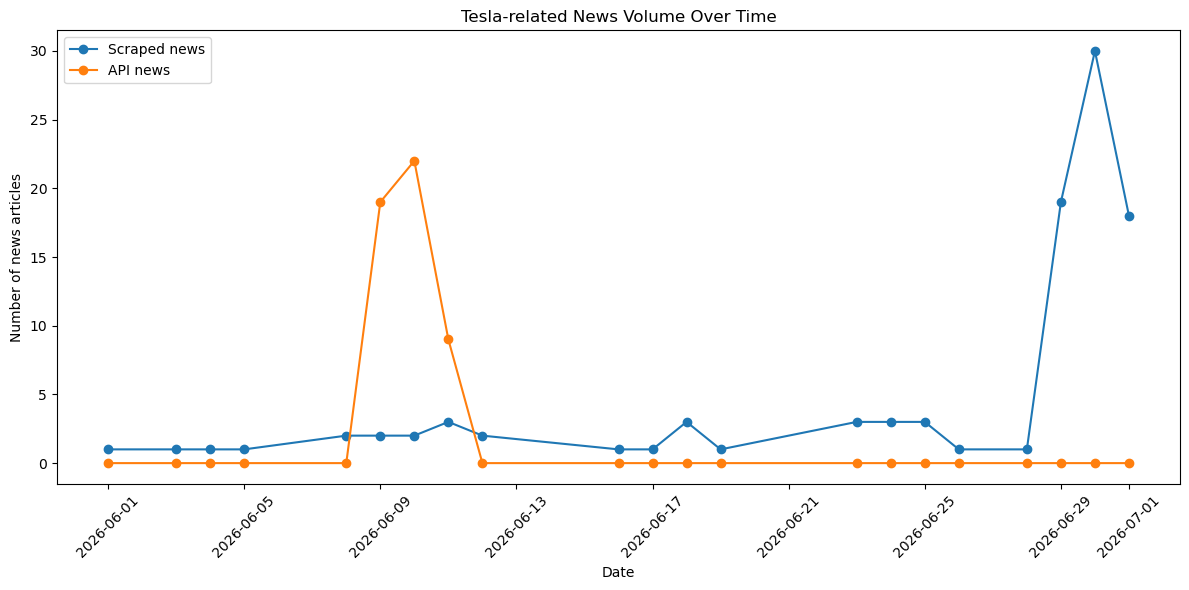

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(merged_df["Date"], merged_df["scraped_news_count"], marker="o", label="Scraped news")
plt.plot(merged_df["Date"], merged_df["api_news_count"], marker="o", label="API news")

plt.title("Tesla-related News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of news articles")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

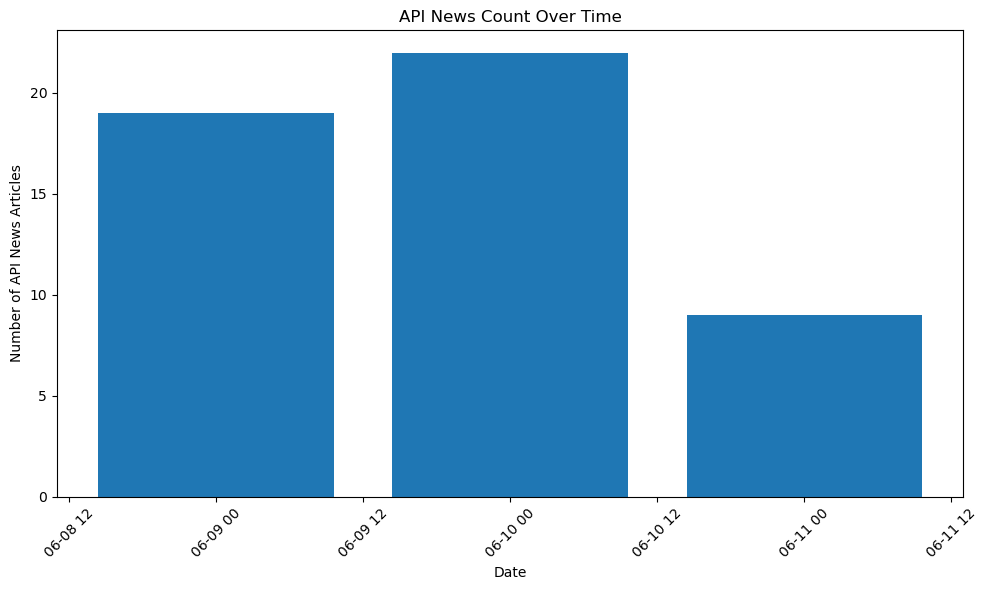

In [13]:
api_news_days = merged_df[merged_df["api_news_count"] > 0].copy()

plt.figure(figsize=(10, 6))

plt.bar(api_news_days["Date"], api_news_days["api_news_count"])

plt.title("API News Count Over Time")
plt.xlabel("Date")
plt.ylabel("Number of API News Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization: API News Sentiment Over Time

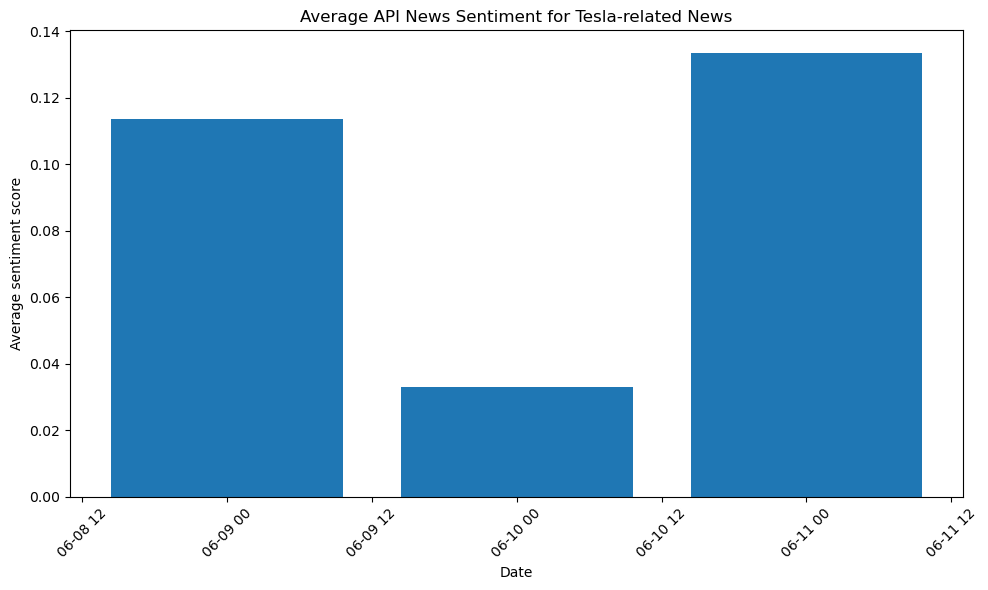

In [14]:
api_sentiment_days = merged_df[merged_df["api_news_count"] > 0].copy()

plt.figure(figsize=(10, 6))

plt.bar(api_sentiment_days["Date"], api_sentiment_days["avg_api_sentiment"])

plt.title("Average API News Sentiment for Tesla-related News")
plt.xlabel("Date")
plt.ylabel("Average sentiment score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Data Availability

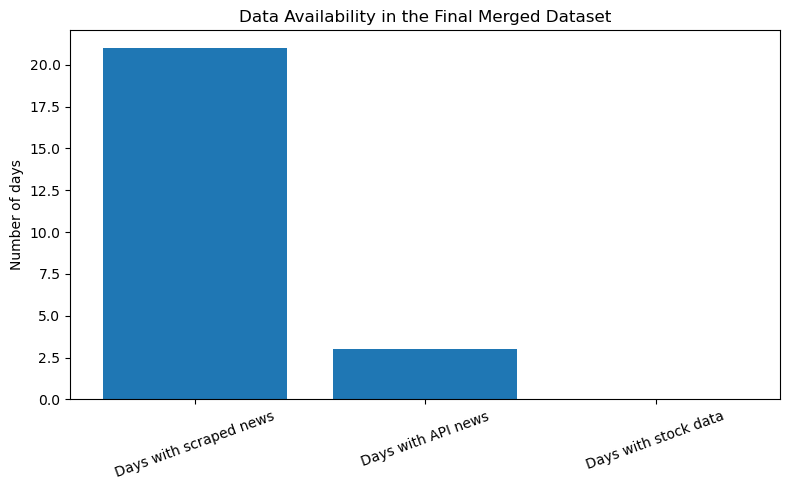

{'Days with scraped news': 21,
 'Days with API news': 3,
 'Days with stock data': 0}

In [15]:
summary_values = {
    "Days with scraped news": (merged_df["scraped_news_count"] > 0).sum(),
    "Days with API news": (merged_df["api_news_count"] > 0).sum(),
    "Days with stock data": merged_df["has_stock_data"].sum()
}

plt.figure(figsize=(8, 5))

plt.bar(summary_values.keys(), summary_values.values())

plt.title("Data Availability in the Final Merged Dataset")
plt.ylabel("Number of days")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

summary_values

# Short Conclusion

The final merged dataset keeps all relevant dates from the stock file, web scraping source and REST API source. This is important because the local Tesla stock CSV ends earlier than the newest news records. The `has_stock_data` column shows which rows have market data, while `scraped_news_count`, `api_news_count`, `avg_api_sentiment` and `total_news_count` preserve the news story for later Kafka and Spark processing.